## 🎯 Goal of Notebook 05

By the end of this notebook, we should be able to answer:

“How accurately can RetailIQ predict future product demand?”

## 📈 Notebook 05 — Demand Forecasting
### SECTION A — Setup
### STEP 1 — Import Libraries

In [2]:
# STEP 1 — Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

print("Libraries imported successfully.")

Libraries imported successfully.


### STEP 2 — Load Feature-Engineered Dataset

In [3]:
# STEP 2 — Load Feature-Engineered Dataset

df = pd.read_csv(
    "../data/processed/feature_engineered_data.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (76000, 40)


### STEP 3 — Inspect the Dataset

In [4]:
# STEP 3 — Inspect Dataset

print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

        Date Store ID Product ID     Category Region  Inventory Level  \
0 2022-01-01     S001      P0001  Electronics  North              195   
1 2022-01-02     S001      P0001  Electronics  North               93   
2 2022-01-03     S001      P0001  Electronics  North              274   
3 2022-01-04     S001      P0001  Electronics  North              132   
4 2022-01-05     S001      P0001  Electronics  North              319   

   Units Sold  Units Ordered  Price  Discount  ... Demand_Lag_28  \
0         102            252  72.72         5  ...           NaN   
1          71              0  65.63         5  ...           NaN   
2         142            229  68.55        15  ...           NaN   
3          42              0  61.66        10  ...           NaN   
4         129              0  59.56        25  ...           NaN   

   Demand_Rolling_Mean_7  Demand_Rolling_Mean_14 Demand_Rolling_Mean_28  \
0                    NaN                     NaN                    NaN   
1 

## SECTION B — Prepare Forecasting Data
### STEP 4 — Sort Data Chronologically

In [5]:
# STEP 4 — Sort Data Chronologically

df = df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

print(
    df[
        ["Date", "Store ID", "Product ID", "Demand"]
    ].head(20)
)

         Date Store ID Product ID  Demand
0  2022-01-01     S001      P0001     115
1  2022-01-02     S001      P0001      84
2  2022-01-03     S001      P0001     132
3  2022-01-04     S001      P0001      67
4  2022-01-05     S001      P0001     110
5  2022-01-06     S001      P0001     146
6  2022-01-07     S001      P0001      87
7  2022-01-08     S001      P0001     113
8  2022-01-09     S001      P0001      87
9  2022-01-10     S001      P0001      99
10 2022-01-11     S001      P0001     103
11 2022-01-12     S001      P0001      85
12 2022-01-13     S001      P0001      77
13 2022-01-14     S001      P0001      52
14 2022-01-15     S001      P0001     175
15 2022-01-16     S001      P0001     126
16 2022-01-17     S001      P0001     102
17 2022-01-18     S001      P0001     102
18 2022-01-19     S001      P0001     123
19 2022-01-20     S001      P0001      25


### STEP 5 — Check Date Range

In [6]:
# STEP 5 — Check Date Range

print("Minimum Date:", df["Date"].min())
print("Maximum Date:", df["Date"].max())

print(
    "Number of unique dates:",
    df["Date"].nunique()
)

Minimum Date: 2022-01-01 00:00:00
Maximum Date: 2024-01-30 00:00:00
Number of unique dates: 760


### STEP 6 — Check Missing Values

In [7]:
# STEP 6 — Check Missing Values

missing_values = df.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ]
)

Demand_Lag_1                100
Demand_Lag_7                700
Demand_Lag_14              1400
Demand_Lag_28              2800
Demand_Rolling_Mean_7       700
Demand_Rolling_Mean_14     1400
Demand_Rolling_Mean_28     2800
Demand_Rolling_Std_7        700
Demand_Lag_2                200
Demand_Change_1             200
Demand_Change_7            1400
Inventory_Gap               700
Inventory_Coverage_Days     700
dtype: int64


### STEP 7 — Remove Rows Without Required Historical Features

For forecasting, we need sufficient historical demand information.

In [8]:
# STEP 7 — Remove Rows Without Required Historical Features

required_history = [
    "Demand_Lag_1",
    "Demand_Lag_7",
    "Demand_Lag_14",
    "Demand_Lag_28",
    "Demand_Rolling_Mean_7",
    "Demand_Rolling_Mean_14",
    "Demand_Rolling_Mean_28"
]

df_model = df.dropna(
    subset=required_history
).copy()

print("Original shape:", df.shape)
print("Modeling shape:", df_model.shape)

Original shape: (76000, 40)
Modeling shape: (73200, 40)


## SECTION C — Understand the Forecasting Problem
### STEP 8 — Check the Forecasting Target

In [9]:
# STEP 8 — Forecasting Target

target = "Demand"

print("Target variable:", target)

print("\nTarget statistics:")
print(
    df_model[target].describe()
)

Target variable: Demand

Target statistics:
count    73200.000000
mean       104.060178
std         47.073491
min          4.000000
25%         71.000000
50%        100.000000
75%        132.000000
max        430.000000
Name: Demand, dtype: float64


### STEP 9 — Visualize Overall Demand Over Time

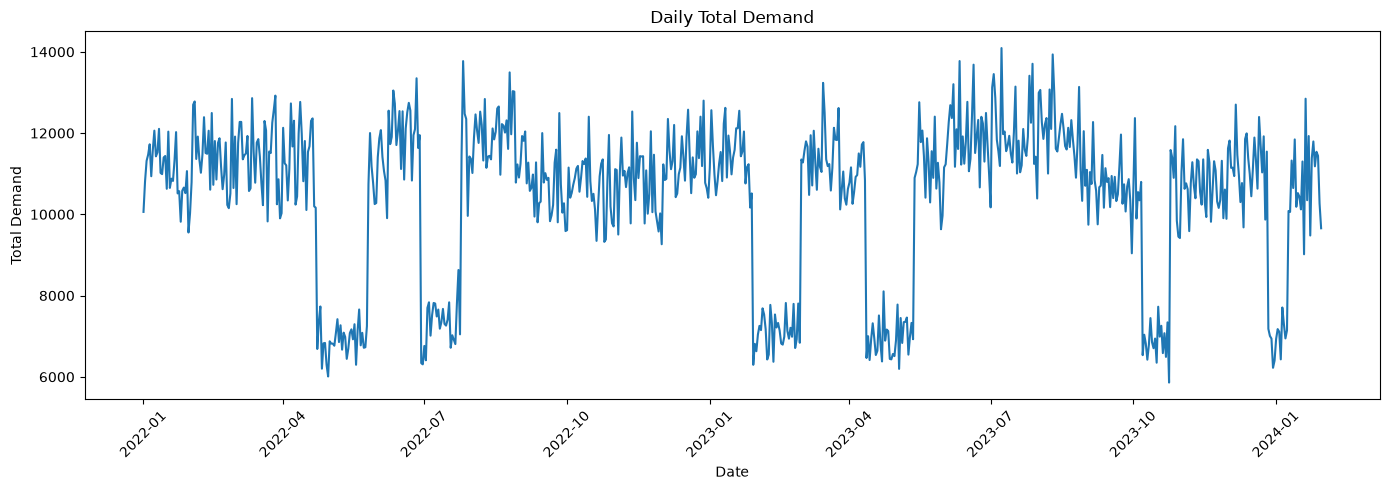

In [11]:
# STEP 9 — Overall Demand Trend

daily_demand = (
    df.groupby("Date")["Demand"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["Date"],
    daily_demand["Demand"]
)

plt.title("Daily Total Demand")
plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## SECTION D — Baseline Forecasts

Before using ML, we establish simple forecasting baselines.

### STEP 10 — Naive Forecast

The naive approach assumes:

Today's future demand ≈ previous day's demand.

In [12]:
# STEP 10 — Naive Forecast

df_baseline = df_model.copy()

df_baseline["Naive_Forecast"] = (
    df_baseline["Demand_Lag_1"]
)

naive_actual = df_baseline["Demand"]

naive_pred = (
    df_baseline["Naive_Forecast"]
)

naive_mae = mean_absolute_error(
    naive_actual,
    naive_pred
)

naive_rmse = np.sqrt(
    mean_squared_error(
        naive_actual,
        naive_pred
    )
)

print(
    "Naive Forecast MAE :",
    naive_mae
)

print(
    "Naive Forecast RMSE:",
    naive_rmse
)

Naive Forecast MAE : 41.09219945355191
Naive Forecast RMSE: 53.511541960130614


### STEP 11 — Moving Average Forecast

Here we use the previous 7 days' average demand.

In [13]:
# STEP 11 — Moving Average Forecast

df_baseline["Moving_Average_7"] = (
    df_baseline["Demand_Rolling_Mean_7"]
)

ma_actual = df_baseline["Demand"]

ma_pred = (
    df_baseline["Moving_Average_7"]
)

ma_mae = mean_absolute_error(
    ma_actual,
    ma_pred
)

ma_rmse = np.sqrt(
    mean_squared_error(
        ma_actual,
        ma_pred
    )
)

print(
    "7-Day Moving Average MAE :",
    ma_mae
)

print(
    "7-Day Moving Average RMSE:",
    ma_rmse
)

7-Day Moving Average MAE : 32.14505659640906
7-Day Moving Average RMSE: 41.6779362823504


## SECTION E — Time-Based Train/Test Split
### STEP 12 — Time-Based Train/Test Split

For forecasting, we must not randomly split the data.

**We want:**

- Past → Training
- Future → Testing

In [14]:
# STEP 12 — Time-Based Train/Test Split

unique_dates = sorted(
    df_model["Date"].unique()
)

split_index = int(
    len(unique_dates) * 0.80
)

train_end_date = (
    unique_dates[split_index - 1]
)

test_start_date = (
    unique_dates[split_index]
)

train_df = df_model[
    df_model["Date"] <= train_end_date
].copy()

test_df = df_model[
    df_model["Date"] >= test_start_date
].copy()

print("Training period:")
print(
    train_df["Date"].min(),
    "to",
    train_df["Date"].max()
)

print("\nTesting period:")
print(
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)

print(
    "\nTraining shape:",
    train_df.shape
)

print(
    "Testing shape :",
    test_df.shape
)

Training period:
2022-01-29 00:00:00 to 2023-09-05 00:00:00

Testing period:
2023-09-06 00:00:00 to 2024-01-30 00:00:00

Training shape: (58500, 40)
Testing shape : (14700, 40)


## SECTION F — Define Features
### STEP 13 — Select Modeling Features

We will initially use historical demand, time, product/store and business-context features.

We deliberately exclude:

Demand
Units Sold
Units Ordered
Inventory Level
Inventory_Gap
Inventory_Coverage_Days

because their availability at prediction time needs careful treatment and some can introduce leakage.

In [16]:
# STEP 13 — Define Modeling Features

feature_columns = [

    # Identity
    "Store ID",
    "Product ID",

    # Categorical business information
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",

    # Time features
    "Year",
    "Month",
    "Quarter",
    "Day",
    "DayOfWeek",
    "IsWeekend",

    # Promotion and discount
    "Promotion",
    "Promotion_Flag",
    "Discount",
    "Discount_Pct",

    # Pricing
    "Price",
    "Competitor Pricing",
    "Price_Difference",
    "Price_Ratio",

    # External factor
    "Epidemic",

    # Historical demand
    "Demand_Lag_1",
    "Demand_Lag_2",
    "Demand_Lag_7",
    "Demand_Lag_14",
    "Demand_Lag_28",

    # Rolling demand statistics
    "Demand_Rolling_Mean_7",
    "Demand_Rolling_Mean_14",
    "Demand_Rolling_Mean_28",
    "Demand_Rolling_Std_7"
]

target = "Demand"

print(
    "Number of features:",
    len(feature_columns)
)

print("\nFeatures:")

for feature in feature_columns:
    print(feature)

Number of features: 30

Features:
Store ID
Product ID
Category
Region
Weather Condition
Seasonality
Year
Month
Quarter
Day
DayOfWeek
IsWeekend
Promotion
Promotion_Flag
Discount
Discount_Pct
Price
Competitor Pricing
Price_Difference
Price_Ratio
Epidemic
Demand_Lag_1
Demand_Lag_2
Demand_Lag_7
Demand_Lag_14
Demand_Lag_28
Demand_Rolling_Mean_7
Demand_Rolling_Mean_14
Demand_Rolling_Mean_28
Demand_Rolling_Std_7


## SECTION G — Prepare X and y
### STEP 14 — Create X and y

In [17]:
# STEP 14 — Create X and y

X_train = train_df[
    feature_columns
]

y_train = train_df[
    target
]

X_test = test_df[
    feature_columns
]

y_test = test_df[
    target
]

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "\nX_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (58500, 30)
y_train: (58500,)

X_test: (14700, 30)
y_test: (14700,)


## SECTION H — Preprocessing
### STEP 15 — Identify Feature Types

In [18]:
# STEP 15 — Identify Feature Types

categorical_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

numerical_features = [
    col
    for col in feature_columns
    if col not in categorical_features
]

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Numerical features:",
    len(numerical_features)
)

Categorical features: 6
Numerical features: 24


### STEP 16 — Create Preprocessing Pipeline

In [19]:
# STEP 16 — Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),

        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print(
    "Preprocessing pipeline created."
)

Preprocessing pipeline created.


## SECTION I — Linear Regression
### STEP 17 — Build Linear Regression Model

In [20]:
# STEP 17 — Linear Regression Model

linear_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

print(
    "Linear Regression model trained successfully."
)

Linear Regression model trained successfully.


### STEP 18 — Predict Using Linear Regression

In [21]:
# STEP 18 — Linear Regression Predictions

linear_predictions = (
    linear_model.predict(X_test)
)

print(
    "Predictions generated."
)

print(
    "First 10 predictions:"
)

print(
    linear_predictions[:10]
)

Predictions generated.
First 10 predictions:
[106.86535611  87.72713891  87.05787083  84.30379996  92.83042359
 136.35700901  98.06970285 113.88918328 135.6690467  121.02741744]


## SECTION J — Model Evaluation
### STEP 19 — Create Evaluation Function

In [22]:
# STEP 19 — Model Evaluation Function

def evaluate_model(
    actual,
    predicted,
    model_name
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### STEP 20 — Evaluate Linear Regression

In [23]:
# STEP 20 — Evaluate Linear Regression

linear_results = evaluate_model(
    y_test,
    linear_predictions,
    "Linear Regression"
)

print(
    linear_results
)

{'Model': 'Linear Regression', 'MAE': 25.351812488552362, 'RMSE': np.float64(32.695136918511146), 'R2': 0.4522778659000034}


## SECTION K — Random Forest
### STEP 21 — Build Random Forest Model

In [24]:
# STEP 21 — Random Forest Model

rf_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=20,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest model trained successfully."
)

Random Forest model trained successfully.


### STEP 22 — Random Forest Predictions

In [25]:
# STEP 22 — Random Forest Predictions

rf_predictions = (
    rf_model.predict(X_test)
)

print(
    "First 10 predictions:"
)

print(
    rf_predictions[:10]
)

First 10 predictions:
[102.28508771  90.55561028  84.75957384  82.99753204  95.20250209
 128.45536324  87.42716436 110.05309606 126.14724836 115.19170165]


### STEP 23 — Evaluate Random Forest

In [26]:
# STEP 23 — Evaluate Random Forest

rf_results = evaluate_model(
    y_test,
    rf_predictions,
    "Random Forest"
)

print(
    rf_results
)

{'Model': 'Random Forest', 'MAE': 20.14534089697044, 'RMSE': np.float64(27.553213468856885), 'R2': 0.611009957132498}


## SECTION L — XGBoost
### STEP 24 — Check XGBoost

In [28]:
# STEP 24 — Check XGBoost

try:

    import xgboost as xgb

    print(
        "XGBoost version:",
        xgb.__version__
    )

except ImportError:

    print(
        "XGBoost is not installed."
    )

XGBoost version: 3.2.0


### STEP 25 — Build XGBoost Model

In [29]:
# STEP 25 — XGBoost Model

xgb_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            xgb.XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

print(
    "XGBoost model trained successfully."
)

XGBoost model trained successfully.


### STEP 26 — XGBoost Predictions

In [30]:
# STEP 26 — XGBoost Predictions

xgb_predictions = (
    xgb_model.predict(X_test)
)

print(
    "First 10 predictions:"
)

print(
    xgb_predictions[:10]
)

First 10 predictions:
[111.802635  97.33053   91.69735   88.84326  119.13609  112.861565
  87.984344 103.67423  132.35631   88.88332 ]


### STEP 27 — Evaluate XGBoost

In [31]:
# STEP 27 — Evaluate XGBoost

xgb_results = evaluate_model(
    y_test,
    xgb_predictions,
    "XGBoost"
)

print(
    xgb_results
)

{'Model': 'XGBoost', 'MAE': 10.362648963928223, 'RMSE': np.float64(14.886166780799591), 'R2': 0.8864571452140808}


## SECTION M — Compare All Models
### STEP 28 — Create Model Comparison Table

In [32]:
# STEP 28 — Model Comparison

results = pd.DataFrame([

    {
        "Model": "Naive Forecast",
        "MAE": naive_mae,
        "RMSE": naive_rmse,
        "R2": np.nan
    },

    {
        "Model": "7-Day Moving Average",
        "MAE": ma_mae,
        "RMSE": ma_rmse,
        "R2": np.nan
    },

    linear_results,
    rf_results,
    xgb_results

])

print(results)

                  Model        MAE       RMSE        R2
0        Naive Forecast  41.092199  53.511542       NaN
1  7-Day Moving Average  32.145057  41.677936       NaN
2     Linear Regression  25.351812  32.695137  0.452278
3         Random Forest  20.145341  27.553213  0.611010
4               XGBoost  10.362649  14.886167  0.886457


### STEP 29 — Sort Models by MAE

In [45]:
# STEP 29 — Sort Models by MAE

results_sorted = (
    results
    .sort_values("MAE")
    .reset_index(drop=True)
)

print(
    results_sorted
)

                  Model        MAE       RMSE        R2
0               XGBoost  10.362649  14.886167  0.886457
1         Random Forest  20.145341  27.553213  0.611010
2     Linear Regression  25.351812  32.695137  0.452278
3  7-Day Moving Average  32.145057  41.677936       NaN
4        Naive Forecast  41.092199  53.511542       NaN


## SECTION N — Visual Model Comparison
### STEP 30 — MAE Comparison

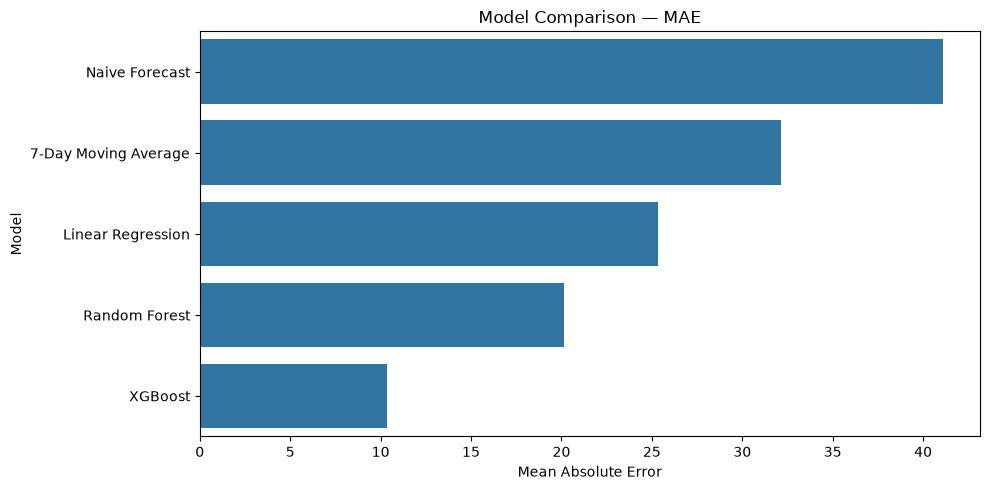

In [46]:
# STEP 30 — MAE Comparison

plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=results,
    x="MAE",
    y="Model"
)

plt.title(
    "Model Comparison — MAE"
)

plt.xlabel(
    "Mean Absolute Error"
)

plt.ylabel(
    "Model"
)

plt.tight_layout()
plt.show()

### STEP 31 — RMSE Comparison

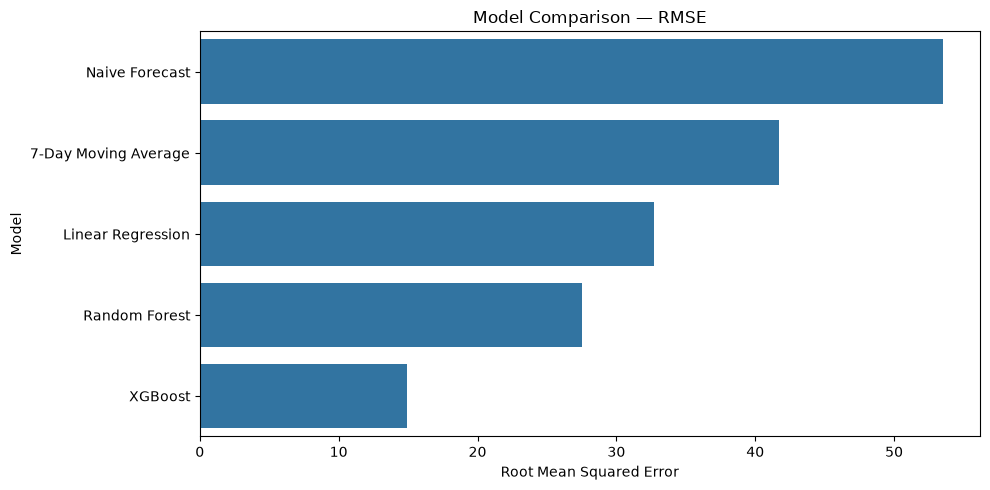

In [47]:
# STEP 31 — RMSE Comparison

plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=results,
    x="RMSE",
    y="Model"
)

plt.title(
    "Model Comparison — RMSE"
)

plt.xlabel(
    "Root Mean Squared Error"
)

plt.ylabel(
    "Model"
)

plt.tight_layout()
plt.show()

## SECTION O — Actual vs Predicted
### STEP 32 — Create Prediction Comparison DataFrame

In [48]:
# STEP 32 — Actual vs Predicted

comparison_df = test_df[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Demand"
    ]
].copy()

comparison_df[
    "Predicted_Demand"
] = xgb_predictions

print(
    comparison_df.head(20)
)

          Date Store ID Product ID  Demand  Predicted_Demand
613 2023-09-06     S001      P0001     115        111.802635
614 2023-09-07     S001      P0001     103         97.330528
615 2023-09-08     S001      P0001      96         91.697350
616 2023-09-09     S001      P0001      80         88.843262
617 2023-09-10     S001      P0001     164        119.136093
618 2023-09-11     S001      P0001     108        112.861565
619 2023-09-12     S001      P0001      83         87.984344
620 2023-09-13     S001      P0001     108        103.674232
621 2023-09-14     S001      P0001     133        132.356308
622 2023-09-15     S001      P0001      49         88.883324
623 2023-09-16     S001      P0001      72         77.199776
624 2023-09-17     S001      P0001      96         98.438217
625 2023-09-18     S001      P0001     120        116.965340
626 2023-09-19     S001      P0001     103        112.295845
627 2023-09-20     S001      P0001     103        102.368378
628 2023-09-21     S001 

### STEP 33 — Plot Actual vs Predicted

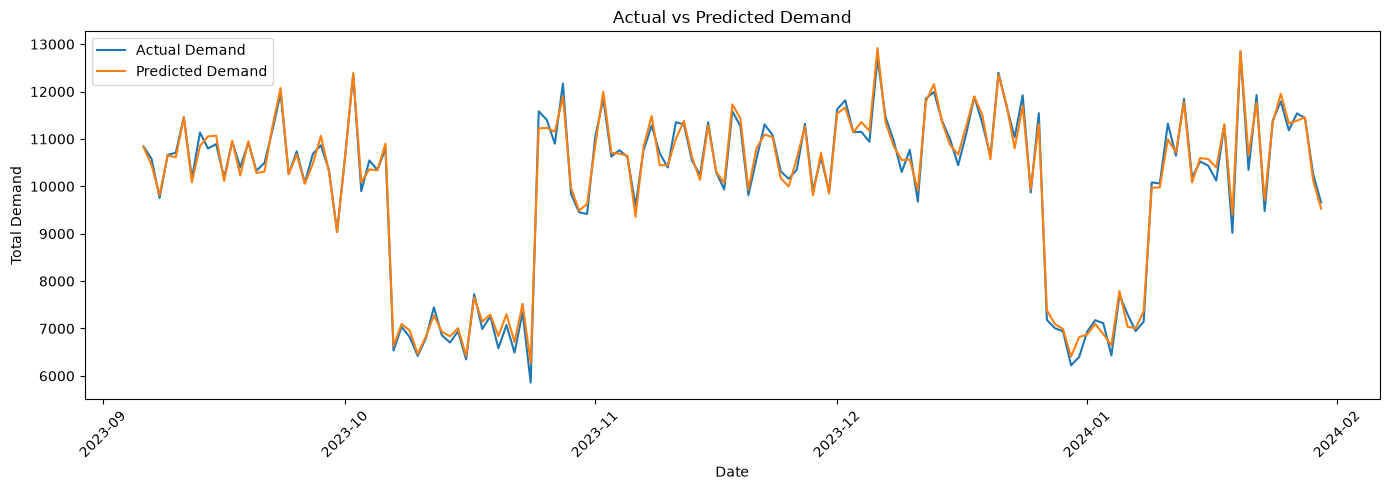

In [49]:
# STEP 33 — Actual vs Predicted Plot

plot_df = (
    comparison_df
    .groupby("Date")[
        [
            "Demand",
            "Predicted_Demand"
        ]
    ]
    .sum()
    .reset_index()
)

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    plot_df["Date"],
    plot_df["Demand"],
    label="Actual Demand"
)

plt.plot(
    plot_df["Date"],
    plot_df["Predicted_Demand"],
    label="Predicted Demand"
)

plt.title(
    "Actual vs Predicted Demand"
)

plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

## SECTION P — Prediction Error Analysis
### STEP 34 — Calculate Prediction Errors

In [50]:
# STEP 34 — Prediction Errors

comparison_df["Error"] = (
    comparison_df["Demand"]
    - comparison_df["Predicted_Demand"]
)

comparison_df["Absolute_Error"] = (
    comparison_df["Error"].abs()
)

print(
    comparison_df[
        [
            "Demand",
            "Predicted_Demand",
            "Error",
            "Absolute_Error"
        ]
    ].head(20)
)

     Demand  Predicted_Demand      Error  Absolute_Error
613     115        111.802635   3.197365        3.197365
614     103         97.330528   5.669472        5.669472
615      96         91.697350   4.302650        4.302650
616      80         88.843262  -8.843262        8.843262
617     164        119.136093  44.863907       44.863907
618     108        112.861565  -4.861565        4.861565
619      83         87.984344  -4.984344        4.984344
620     108        103.674232   4.325768        4.325768
621     133        132.356308   0.643692        0.643692
622      49         88.883324 -39.883324       39.883324
623      72         77.199776  -5.199776        5.199776
624      96         98.438217  -2.438217        2.438217
625     120        116.965340   3.034660        3.034660
626     103        112.295845  -9.295845        9.295845
627     103        102.368378   0.631622        0.631622
628      59         71.901245 -12.901245       12.901245
629      84         83.991951  

### STEP 35 — Error Distribution

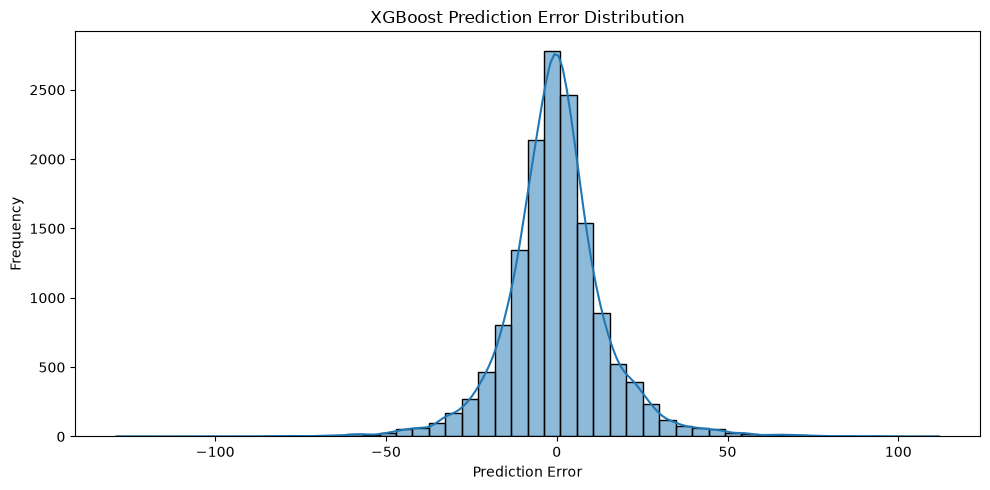

In [51]:
# STEP 35 — Error Distribution

plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    comparison_df["Error"],
    bins=50,
    kde=True
)

plt.title(
    "XGBoost Prediction Error Distribution"
)

plt.xlabel(
    "Prediction Error"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()

## SECTION Q — Feature Importance
### STEP 36 — Extract XGBoost Feature Importance

In [52]:
# STEP 36 — XGBoost Feature Importance

model = (
    xgb_model
    .named_steps["model"]
)

preprocessor_fitted = (
    xgb_model
    .named_steps["preprocessor"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance_values = (
    model.feature_importances_
)

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance_values

})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    feature_importance.head(20)
)

                                 Feature  Importance
0              numerical__Promotion_Flag    0.148810
1                   numerical__Promotion    0.131403
2       numerical__Demand_Rolling_Mean_7    0.056290
3        categorical__Category_Groceries    0.046647
4                    numerical__Epidemic    0.037830
5        categorical__Category_Furniture    0.037471
6         categorical__Category_Clothing    0.029550
7   categorical__Weather Condition_Sunny    0.025216
8             categorical__Category_Toys    0.023397
9        categorical__Seasonality_Summer    0.023112
10     categorical__Category_Electronics    0.020433
11         categorical__Product ID_P0006    0.017138
12         categorical__Product ID_P0013    0.015251
13         categorical__Product ID_P0002    0.014279
14         categorical__Product ID_P0014    0.013846
15     numerical__Demand_Rolling_Mean_14    0.013814
16         categorical__Product ID_P0018    0.013651
17            categorical__Store ID_S005    0.

### STEP 37 — Plot Top 20 Important Features

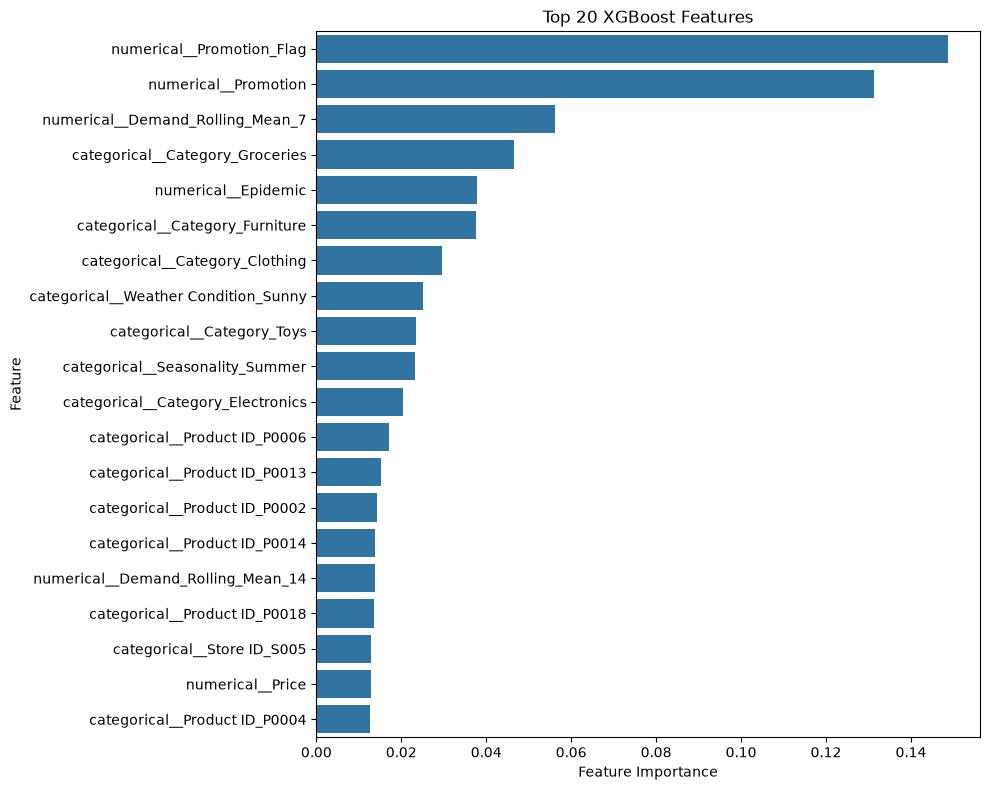

In [53]:
# STEP 37 — Top 20 Important Features

top_features = (
    feature_importance
    .head(20)
)

plt.figure(
    figsize=(10, 8)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 XGBoost Features"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

## SECTION R — Save Results
### STEP 38 — Save Model Comparison

In [54]:
# STEP 38 — Save Model Comparison

results.to_csv(
    "../data/processed/forecasting_model_comparison.csv",
    index=False
)

print(
    "Model comparison saved successfully."
)

Model comparison saved successfully.


### STEP 39 — Save Predictions

In [55]:
# STEP 39 — Save Predictions

comparison_df.to_csv(
    "../data/processed/demand_predictions.csv",
    index=False
)

print(
    "Demand predictions saved successfully."
)

Demand predictions saved successfully.


## SECTION S — Final Summary
### STEP 40 — Final Forecasting Summary

In [56]:
# STEP 40 — Final Forecasting Summary

print("=" * 60)

print(
    "RETAILIQ — DEMAND FORECASTING SUMMARY"
)

print("=" * 60)

print("\nDataset:")

print(
    "Training rows:",
    len(train_df)
)

print(
    "Testing rows :",
    len(test_df)
)

print("\nForecasting period:")

print(
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)

print("\nModel Performance:")

print(
    results_sorted
)

print(
    "\nBest model based on MAE:"
)

print(
    results_sorted.iloc[0]["Model"]
)

print(
    "\nDemand forecasting notebook completed."
)

RETAILIQ — DEMAND FORECASTING SUMMARY

Dataset:
Training rows: 58500
Testing rows : 14700

Forecasting period:
2023-09-06 00:00:00 to 2024-01-30 00:00:00

Model Performance:
                  Model        MAE       RMSE        R2
0               XGBoost  10.362649  14.886167  0.886457
1         Random Forest  20.145341  27.553213  0.611010
2     Linear Regression  25.351812  32.695137  0.452278
3  7-Day Moving Average  32.145057  41.677936       NaN
4        Naive Forecast  41.092199  53.511542       NaN

Best model based on MAE:
XGBoost

Demand forecasting notebook completed.


### STEP 41 — Fix the redundant Promotion feature

In [57]:
# STEP 41 — Check Redundant Features

print("Promotion unique values:")
print(df_model["Promotion"].unique())

print("\nPromotion_Flag unique values:")
print(df_model["Promotion_Flag"].unique())

print(
    "\nAre Promotion and Promotion_Flag identical?"
)

print(
    (df_model["Promotion"] == df_model["Promotion_Flag"]).all()
)

Promotion unique values:
[0 1]

Promotion_Flag unique values:
[0 1]

Are Promotion and Promotion_Flag identical?
True


### STEP 42 — Remove Redundant Promotion_Flag
Update the feature list by removing only **Promotion_Flag**.

In [58]:
# STEP 42 — Remove Redundant Feature

feature_columns_clean = [

    # Identity
    "Store ID",
    "Product ID",

    # Categorical business information
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",

    # Time features
    "Year",
    "Month",
    "Quarter",
    "Day",
    "DayOfWeek",
    "IsWeekend",

    # Promotion and discount
    "Promotion",
    "Discount",
    "Discount_Pct",

    # Pricing
    "Price",
    "Competitor Pricing",
    "Price_Difference",
    "Price_Ratio",

    # External factor
    "Epidemic",

    # Historical demand
    "Demand_Lag_1",
    "Demand_Lag_2",
    "Demand_Lag_7",
    "Demand_Lag_14",
    "Demand_Lag_28",

    # Rolling demand statistics
    "Demand_Rolling_Mean_7",
    "Demand_Rolling_Mean_14",
    "Demand_Rolling_Mean_28",
    "Demand_Rolling_Std_7"
]

print(
    "Original feature count:",
    len(feature_columns)
)

print(
    "Clean feature count:",
    len(feature_columns_clean)
)

print(
    "\nRemoved feature:",
    "Promotion_Flag"
)

Original feature count: 30
Clean feature count: 29

Removed feature: Promotion_Flag


### STEP 43 — Recreate Training and Testing Data

In [59]:
# STEP 43 — Create Clean X and y

X_train_clean = train_df[
    feature_columns_clean
]

y_train_clean = train_df[
    "Demand"
]

X_test_clean = test_df[
    feature_columns_clean
]

y_test_clean = test_df[
    "Demand"
]

print("X_train_clean:", X_train_clean.shape)
print("y_train_clean:", y_train_clean.shape)

print("\nX_test_clean:", X_test_clean.shape)
print("y_test_clean:", y_test_clean.shape)

X_train_clean: (58500, 29)
y_train_clean: (58500,)

X_test_clean: (14700, 29)
y_test_clean: (14700,)


### STEP 44 — Create Clean Preprocessing Pipeline

In [60]:
# STEP 44 — Clean Preprocessing Pipeline

categorical_features_clean = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

numerical_features_clean = [
    col
    for col in feature_columns_clean
    if col not in categorical_features_clean
]

preprocessor_clean = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_clean
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features_clean
        )
    ]
)

print(
    "Categorical features:",
    len(categorical_features_clean)
)

print(
    "Numerical features:",
    len(numerical_features_clean)
)

Categorical features: 6
Numerical features: 23


### STEP 45 — Train Clean XGBoost

In [63]:
# STEP 45 — Clean XGBoost Model

xgb_model_clean = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_clean
        ),
        (
            "model",
            xgb.XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model_clean.fit(
    X_train_clean,
    y_train_clean
)

print(
    "Clean XGBoost model trained successfully."
)

Clean XGBoost model trained successfully.


### STEP 46 — Evaluate Clean XGBoost

In [64]:
# STEP 46 — Evaluate Clean XGBoost

xgb_predictions_clean = (
    xgb_model_clean.predict(
        X_test_clean
    )
)

xgb_clean_results = evaluate_model(
    y_test_clean,
    xgb_predictions_clean,
    "XGBoost — Clean Features"
)

print(
    xgb_clean_results
)

{'Model': 'XGBoost — Clean Features', 'MAE': 10.343194007873535, 'RMSE': np.float64(14.79686365660864), 'R2': 0.8878153562545776}


### STEP 47 — Compare Original vs Clean XGBoost 

In [65]:
# STEP 47 — Compare XGBoost Versions

xgb_comparison = pd.DataFrame([
    xgb_results,
    xgb_clean_results
])

print(
    xgb_comparison
)

                      Model        MAE       RMSE        R2
0                   XGBoost  10.362649  14.886167  0.886457
1  XGBoost — Clean Features  10.343194  14.796864  0.887815


### Step 48 — Interpret Clean XGBoost Results

In [66]:
# Step 48 — Interpret Clean XGBoost Results

print("Clean XGBoost Model Performance")
print("-" * 40)

print(f"MAE : {xgb_clean_results['MAE']:.4f}")
print(f"RMSE: {xgb_clean_results['RMSE']:.4f}")
print(f"R²  : {xgb_clean_results['R2']:.4f}")

print("\nInterpretation:")
print(f"- Average prediction error: {xgb_clean_results['MAE']:.2f} demand units")
print(f"- RMSE: {xgb_clean_results['RMSE']:.2f}")
print(f"- Variance explained: {xgb_clean_results['R2'] * 100:.2f}%")

print("\nComparison with Original XGBoost:")

mae_change = xgb_clean_results["MAE"] - xgb_results["MAE"]
rmse_change = xgb_clean_results["RMSE"] - xgb_results["RMSE"]
r2_change = xgb_clean_results["R2"] - xgb_results["R2"]

print(f"MAE change : {mae_change:.4f}")
print(f"RMSE change: {rmse_change:.4f}")
print(f"R² change  : {r2_change:.4f}")

if (
    xgb_clean_results["MAE"] < xgb_results["MAE"]
    and xgb_clean_results["RMSE"] < xgb_results["RMSE"]
    and xgb_clean_results["R2"] > xgb_results["R2"]
):
    print("\nConclusion: Clean XGBoost performs better.")
else:
    print("\nConclusion: Original XGBoost performs better.")

Clean XGBoost Model Performance
----------------------------------------
MAE : 10.3432
RMSE: 14.7969
R²  : 0.8878

Interpretation:
- Average prediction error: 10.34 demand units
- RMSE: 14.80
- Variance explained: 88.78%

Comparison with Original XGBoost:
MAE change : -0.0195
RMSE change: -0.0893
R² change  : 0.0014

Conclusion: Clean XGBoost performs better.


### Step 49 — Recalculate Baselines on the Same Test Period

In [67]:
# Step 49 — Recalculate Baselines on Test Period

# Naive forecast: previous day's demand
naive_test = test_df["Demand_Lag_1"]

# 7-day moving average forecast
moving_avg_test = test_df["Demand_Rolling_Mean_7"]

# Actual demand
actual_test = test_df["Demand"]

# Evaluate Naive Forecast
naive_test_mae = mean_absolute_error(actual_test, naive_test)
naive_test_rmse = np.sqrt(mean_squared_error(actual_test, naive_test))

# Evaluate 7-Day Moving Average
ma_test_mae = mean_absolute_error(actual_test, moving_avg_test)
ma_test_rmse = np.sqrt(mean_squared_error(actual_test, moving_avg_test))

print("Naive Forecast — Test Period")
print("MAE :", naive_test_mae)
print("RMSE:", naive_test_rmse)

print("\n7-Day Moving Average — Test Period")
print("MAE :", ma_test_mae)
print("RMSE:", ma_test_rmse)

Naive Forecast — Test Period
MAE : 40.091632653061225
RMSE: 51.85106418524944

7-Day Moving Average — Test Period
MAE : 31.60860058309038
RMSE: 40.626436671912884


### Step 50 — Final Fair Model Comparison

In [68]:
# Step 50 — Final Fair Model Comparison

final_comparison = pd.DataFrame([
    {
        "Model": "Naive Forecast",
        "MAE": naive_test_mae,
        "RMSE": naive_test_rmse,
        "R2": np.nan
    },
    {
        "Model": "7-Day Moving Average",
        "MAE": ma_test_mae,
        "RMSE": ma_test_rmse,
        "R2": np.nan
    },
    {
        "Model": "Linear Regression",
        "MAE": linear_results["MAE"],
        "RMSE": linear_results["RMSE"],
        "R2": linear_results["R2"]
    },
    {
        "Model": "Random Forest",
        "MAE": rf_results["MAE"],
        "RMSE": rf_results["RMSE"],
        "R2": rf_results["R2"]
    },
    {
        "Model": "XGBoost — Clean Features",
        "MAE": xgb_clean_results["MAE"],
        "RMSE": xgb_clean_results["RMSE"],
        "R2": xgb_clean_results["R2"]
    }
])

print(final_comparison)

                      Model        MAE       RMSE        R2
0            Naive Forecast  40.091633  51.851064       NaN
1      7-Day Moving Average  31.608601  40.626437       NaN
2         Linear Regression  25.351812  32.695137  0.452278
3             Random Forest  20.145341  27.553213  0.611010
4  XGBoost — Clean Features  10.343194  14.796864  0.887815


Step 51 — Forecasting Results Summary

Your final results are:

| Model                        |     MAE ↓ |    RMSE ↓ |       R² ↑ |
| ---------------------------- | --------: | --------: | ---------: |
| Naive Forecast               |     40.09 |     51.85 |          — |
| 7-Day Moving Average         |     31.61 |     40.63 |          — |
| Linear Regression            |     25.35 |     32.70 |     0.4523 |
| Random Forest                |     20.15 |     27.55 |     0.6110 |
| **XGBoost — Clean Features** | **10.34** | **14.80** | **0.8878** |

What we've established

XGBoost is currently our strongest model in this experiment.

Its test performance means:

Average absolute error ≈ 10.34 demand units
RMSE ≈ 14.80 demand units
R² ≈ 0.888
It substantially improves on both simple forecasting baselines and the other ML models.

But there is an important distinction before we call this the final RetailIQ forecasting model:

A strong test score is not enough. We need to make sure every feature used by the model would genuinely be available when a real inventory manager asks, "How much demand should I expect tomorrow?"

For example, Promotion, Price, Discount, and Weather Condition may or may not be known in advance depending on the forecasting scenario.

### Step 52 — Check Prediction-Time Feature Availability

In [69]:
# Step 52 — Check Prediction-Time Feature Availability

print("Clean XGBoost features:\n")

for i, feature in enumerate(feature_columns_clean, start=1):
    print(f"{i:02d}. {feature}")

Clean XGBoost features:

01. Store ID
02. Product ID
03. Category
04. Region
05. Weather Condition
06. Seasonality
07. Year
08. Month
09. Quarter
10. Day
11. DayOfWeek
12. IsWeekend
13. Promotion
14. Discount
15. Discount_Pct
16. Price
17. Competitor Pricing
18. Price_Difference
19. Price_Ratio
20. Epidemic
21. Demand_Lag_1
22. Demand_Lag_2
23. Demand_Lag_7
24. Demand_Lag_14
25. Demand_Lag_28
26. Demand_Rolling_Mean_7
27. Demand_Rolling_Mean_14
28. Demand_Rolling_Mean_28
29. Demand_Rolling_Std_7


### Step 53 — Classify Forecasting Features

In [70]:
# Step 53 — Classify Forecasting Features

feature_availability = pd.DataFrame({
    "Feature": feature_columns_clean,
    "Availability": [
        "Historical / Static",
        "Historical / Static",
        "Historical / Static",
        "Historical / Static",
        "Known Future / External",
        "Known Future / Calendar",
        "Known Future / Calendar",
        "Known Future / Calendar",
        "Known Future / Calendar",
        "Known Future / Calendar",
        "Known Future / Calendar",
        "Known Future / Calendar",
        "Known Future / Planned",
        "Known Future / Planned",
        "Derived from Known Future",
        "Known Future / Planned",
        "Known Future / External",
        "Derived",
        "Derived",
        "Known Future / External",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical"
    ]
})

print(feature_availability.to_string(index=False))

               Feature              Availability
              Store ID       Historical / Static
            Product ID       Historical / Static
              Category       Historical / Static
                Region       Historical / Static
     Weather Condition   Known Future / External
           Seasonality   Known Future / Calendar
                  Year   Known Future / Calendar
                 Month   Known Future / Calendar
               Quarter   Known Future / Calendar
                   Day   Known Future / Calendar
             DayOfWeek   Known Future / Calendar
             IsWeekend   Known Future / Calendar
             Promotion    Known Future / Planned
              Discount    Known Future / Planned
          Discount_Pct Derived from Known Future
                 Price    Known Future / Planned
    Competitor Pricing   Known Future / External
      Price_Difference                   Derived
           Price_Ratio                   Derived
              Epidem

### Step 54 — Create a Prediction-Time Feature Audit

In [71]:
# Step 54 — Prediction-Time Feature Audit

prediction_time_audit = pd.DataFrame({
    "Feature": feature_columns_clean,
    "Type": [
        "Static",
        "Static",
        "Static",
        "Static",
        "External Future",
        "Calendar",
        "Calendar",
        "Calendar",
        "Calendar",
        "Calendar",
        "Calendar",
        "Calendar",
        "Planned Future",
        "Planned Future",
        "Derived",
        "Planned Future",
        "External Future",
        "Derived",
        "Derived",
        "External Future",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical",
        "Historical"
    ],
    "Available_Before_Demand": [
        True, True, True, True,
        True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True
    ]
})

print(prediction_time_audit.to_string(index=False))

print("\nTotal features:", len(prediction_time_audit))
print(
    "Features available before demand:",
    prediction_time_audit["Available_Before_Demand"].sum()
)

               Feature            Type  Available_Before_Demand
              Store ID          Static                     True
            Product ID          Static                     True
              Category          Static                     True
                Region          Static                     True
     Weather Condition External Future                     True
           Seasonality        Calendar                     True
                  Year        Calendar                     True
                 Month        Calendar                     True
               Quarter        Calendar                     True
                   Day        Calendar                     True
             DayOfWeek        Calendar                     True
             IsWeekend        Calendar                     True
             Promotion  Planned Future                     True
              Discount  Planned Future                     True
          Discount_Pct         Derived  

### Step 55 — Define Historical-Only Forecast Features

Here we remove variables that depend on future planned/external information:

Weather Condition
Promotion
Discount
Discount_Pct
Price
Competitor Pricing
Price_Difference
Price_Ratio
Epidemic

We will retain:

Static product/store information
Calendar information
Historical demand lags
Historical rolling statistics

In [72]:
# Step 55 — Define Historical-Only Forecast Features

historical_only_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Seasonality",
    "Year",
    "Month",
    "Quarter",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Demand_Lag_1",
    "Demand_Lag_2",
    "Demand_Lag_7",
    "Demand_Lag_14",
    "Demand_Lag_28",
    "Demand_Rolling_Mean_7",
    "Demand_Rolling_Mean_14",
    "Demand_Rolling_Mean_28",
    "Demand_Rolling_Std_7"
]

print("Historical-only features:")
for i, feature in enumerate(historical_only_features, start=1):
    print(f"{i:02d}. {feature}")

print("\nTotal historical-only features:", len(historical_only_features))

Historical-only features:
01. Store ID
02. Product ID
03. Category
04. Region
05. Seasonality
06. Year
07. Month
08. Quarter
09. Day
10. DayOfWeek
11. IsWeekend
12. Demand_Lag_1
13. Demand_Lag_2
14. Demand_Lag_7
15. Demand_Lag_14
16. Demand_Lag_28
17. Demand_Rolling_Mean_7
18. Demand_Rolling_Mean_14
19. Demand_Rolling_Mean_28
20. Demand_Rolling_Std_7

Total historical-only features: 20


### Step 56 — Train Historical-Only XGBoost

In [73]:
# Step 56 — Train Historical-Only XGBoost

# Create training and testing datasets
X_train_hist = X_train[historical_only_features]
X_test_hist = X_test[historical_only_features]

y_train_hist = y_train.copy()
y_test_hist = y_test.copy()

print("X_train_hist:", X_train_hist.shape)
print("X_test_hist :", X_test_hist.shape)
print("y_train_hist:", y_train_hist.shape)
print("y_test_hist :", y_test_hist.shape)

X_train_hist: (58500, 20)
X_test_hist : (14700, 20)
y_train_hist: (58500,)
y_test_hist : (14700,)


### Step 57 — Build Historical-Only Preprocessing Pipeline

In [74]:
# Step 57 — Historical-Only Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify categorical and numerical features
categorical_hist = X_train_hist.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_hist = X_train_hist.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:", categorical_hist)
print("\nNumerical features:", numerical_hist)

# Preprocessing
preprocessor_hist = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_hist
        ),
        (
            "numerical",
            "passthrough",
            numerical_hist
        )
    ]
)

# Transform training and testing data
X_train_hist_processed = preprocessor_hist.fit_transform(X_train_hist)
X_test_hist_processed = preprocessor_hist.transform(X_test_hist)

print("\nProcessed training shape:", X_train_hist_processed.shape)
print("Processed testing shape :", X_test_hist_processed.shape)

Categorical features: ['Store ID', 'Product ID', 'Category', 'Region', 'Seasonality']

Numerical features: ['Year', 'Month', 'Quarter', 'Day', 'DayOfWeek', 'IsWeekend', 'Demand_Lag_1', 'Demand_Lag_2', 'Demand_Lag_7', 'Demand_Lag_14', 'Demand_Lag_28', 'Demand_Rolling_Mean_7', 'Demand_Rolling_Mean_14', 'Demand_Rolling_Mean_28', 'Demand_Rolling_Std_7']

Processed training shape: (58500, 53)
Processed testing shape : (14700, 53)


C:\Users\dhanu\AppData\Local\Temp\ipykernel_47768\487510291.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_hist = X_train_hist.select_dtypes(


### Step 58 — Train Historical-Only XGBoost

In [75]:
# Step 58 — Train Historical-Only XGBoost

xgb_hist = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_hist.fit(
    X_train_hist_processed,
    y_train_hist
)

print("Historical-only XGBoost training completed.")

Historical-only XGBoost training completed.


### Step 59 — Generate Historical-Only Predictions

In [76]:
# Step 59 — Generate Historical-Only Predictions

y_pred_hist = xgb_hist.predict(X_test_hist_processed)

print("Historical-only predictions generated.")
print("Number of predictions:", len(y_pred_hist))

Historical-only predictions generated.
Number of predictions: 14700


### Step 60 — Evaluate Historical-Only XGBoost

In [77]:
# Step 60 — Evaluate Historical-Only XGBoost

hist_mae = mean_absolute_error(y_test_hist, y_pred_hist)
hist_rmse = np.sqrt(mean_squared_error(y_test_hist, y_pred_hist))
hist_r2 = r2_score(y_test_hist, y_pred_hist)

xgb_hist_results = {
    "Model": "XGBoost — Historical Only",
    "MAE": hist_mae,
    "RMSE": hist_rmse,
    "R2": hist_r2
}

print("Historical-Only XGBoost Results")
print("MAE :", hist_mae)
print("RMSE:", hist_rmse)
print("R2  :", hist_r2)

Historical-Only XGBoost Results
MAE : 32.42414474487305
RMSE: 40.712852724331725
R2  : 0.15070801973342896


### Step 61 — Compare Conditional vs Historical-Only XGBoost

In [78]:
# Step 61 — Compare Conditional vs Historical-Only XGBoost

conditional_results = {
    "Model": "XGBoost — Clean Features",
    "MAE": xgb_clean_results["MAE"],
    "RMSE": xgb_clean_results["RMSE"],
    "R2": xgb_clean_results["R2"]
}

forecast_scenario_comparison = pd.DataFrame([
    conditional_results,
    xgb_hist_results
])

print(forecast_scenario_comparison)

                       Model        MAE       RMSE        R2
0   XGBoost — Clean Features  10.343194  14.796864  0.887815
1  XGBoost — Historical Only  32.424145  40.712853  0.150708


### Step 62 — Calculate Performance Difference

In [79]:
# Step 62 — Calculate Performance Difference

conditional_mae = xgb_clean_results["MAE"]
historical_mae = xgb_hist_results["MAE"]

conditional_rmse = xgb_clean_results["RMSE"]
historical_rmse = xgb_hist_results["RMSE"]

conditional_r2 = xgb_clean_results["R2"]
historical_r2 = xgb_hist_results["R2"]

print("Performance Difference")
print("----------------------")

print(
    "MAE difference:",
    historical_mae - conditional_mae
)

print(
    "RMSE difference:",
    historical_rmse - conditional_rmse
)

print(
    "R2 difference:",
    conditional_r2 - historical_r2
)

Performance Difference
----------------------
MAE difference: 22.08095073699951
RMSE difference: 25.915989067723086
R2 difference: 0.7371073365211487


### Step 63 — Create Final Forecasting Model Comparison

In [80]:
# Step 63 — Create Final Forecasting Model Comparison

final_forecasting_comparison = pd.DataFrame([
    {
        "Model": "Naive Forecast",
        "MAE": naive_test_mae,
        "RMSE": naive_test_rmse,
        "R2": np.nan
    },
    {
        "Model": "7-Day Moving Average",
        "MAE": ma_test_mae,
        "RMSE": ma_test_rmse,
        "R2": np.nan
    },
    {
        "Model": "Linear Regression",
        "MAE": linear_results["MAE"],
        "RMSE": linear_results["RMSE"],
        "R2": linear_results["R2"]
    },
    {
        "Model": "Random Forest",
        "MAE": rf_results["MAE"],
        "RMSE": rf_results["RMSE"],
        "R2": rf_results["R2"]
    },
    {
        "Model": "XGBoost — Historical Only",
        "MAE": xgb_hist_results["MAE"],
        "RMSE": xgb_hist_results["RMSE"],
        "R2": xgb_hist_results["R2"]
    },
    {
        "Model": "XGBoost — Clean Features",
        "MAE": xgb_clean_results["MAE"],
        "RMSE": xgb_clean_results["RMSE"],
        "R2": xgb_clean_results["R2"]
    }
])

final_forecasting_comparison = final_forecasting_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

print(final_forecasting_comparison)

                       Model        MAE       RMSE        R2
0   XGBoost — Clean Features  10.343194  14.796864  0.887815
1              Random Forest  20.145341  27.553213  0.611010
2          Linear Regression  25.351812  32.695137  0.452278
3       7-Day Moving Average  31.608601  40.626437       NaN
4  XGBoost — Historical Only  32.424145  40.712853  0.150708
5             Naive Forecast  40.091633  51.851064       NaN


### Step 64 — Save Final Forecasting Results

In [81]:
# Step 64 — Save Final Forecasting Results

import os

results_path = "../data/processed/demand_forecasting_results.csv"

final_forecasting_comparison.to_csv(
    results_path,
    index=False
)

print("Forecasting results saved to:")
print(results_path)

Forecasting results saved to:
../data/processed/demand_forecasting_results.csv


### Step 65 — Final Notebook 05 Summary

In [82]:
# Step 65 — Final Notebook 05 Summary

print("=" * 60)
print("RETAILIQ — NOTEBOOK 05: DEMAND FORECASTING")
print("=" * 60)

print("\nDataset:")
print("Training rows :", len(X_train))
print("Testing rows  :", len(X_test))

print("\nBest Conditional Model:")
print("Model :", xgb_clean_results["Model"])
print("MAE   :", round(xgb_clean_results["MAE"], 4))
print("RMSE  :", round(xgb_clean_results["RMSE"], 4))
print("R2    :", round(xgb_clean_results["R2"], 4))

print("\nHistorical-Only Model:")
print("Model :", xgb_hist_results["Model"])
print("MAE   :", round(xgb_hist_results["MAE"], 4))
print("RMSE  :", round(xgb_hist_results["RMSE"], 4))
print("R2    :", round(xgb_hist_results["R2"], 4))

print("\nBaseline:")
print("Naive MAE            :", round(naive_test_mae, 4))
print("7-Day Moving Avg MAE :", round(ma_test_mae, 4))

print("\nSaved Results:")
print(results_path)

print("\nNotebook 05 validation completed.")

RETAILIQ — NOTEBOOK 05: DEMAND FORECASTING

Dataset:
Training rows : 58500
Testing rows  : 14700

Best Conditional Model:
Model : XGBoost — Clean Features
MAE   : 10.3432
RMSE  : 14.7969
R2    : 0.8878

Historical-Only Model:
Model : XGBoost — Historical Only
MAE   : 32.4241
RMSE  : 40.7129
R2    : 0.1507

Baseline:
Naive MAE            : 40.0916
7-Day Moving Avg MAE : 31.6086

Saved Results:
../data/processed/demand_forecasting_results.csv

Notebook 05 validation completed.
